![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, f1_score

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [8]:
data.shape

(10495, 10)

In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [ ]:
# Celda 1

def variance(y):
    return 0 if len(y) == 0 else np.var(y)

def variance_reduction(X_col, y, split):
    left  = y[X_col < split]
    right = y[X_col >= split]
    n, n_l, n_r = len(y), len(left), len(right)
    if n_l == 0 or n_r == 0:
        return 0
    return variance(y) - (n_l/n)*variance(left) - (n_r/n)*variance(right)

def best_split(X, y, num_pct=10):
    best = [0, 0, -np.inf]      
    for j in range(X.shape[1]):
        splits = np.unique(np.percentile(X.iloc[:, j], np.linspace(0, 100, num_pct)))
        for split in splits:
            gain = variance_reduction(X.iloc[:, j], y, split)
            if gain > best[2]:
                best = [j, split, gain]
    return best

def tree_grow(X, y, depth=0, max_depth=3, min_samples=10):
    if len(y) <= min_samples or depth >= max_depth:
        return {"prediction": y.mean()}
    j, split, gain = best_split(X, y)
    if gain <= 0:
        return {"prediction": y.mean()}
    mask = X.iloc[:, j] < split
    return {
        "feature":  j,
        "feature_name": X.columns[j],
        "split":    split,
        "left":     tree_grow(X[mask],  y[mask],  depth+1, max_depth, min_samples),
        "right":    tree_grow(X[~mask], y[~mask], depth+1, max_depth, min_samples),
    }

def tree_predict(X, tree):
    preds = []
    for i in range(len(X)):
        node = tree
        while "prediction" not in node:
            if X.iloc[i, node["feature"]] < node["split"]:
                node = node["left"]
            else:
                node = node["right"]
        preds.append(node["prediction"])
    return np.array(preds)

In [ ]:
X_train = X_train.astype(float)
X_test  = X_test.astype(float)
y_train = y_train.astype(float)
y_test  = y_test.astype(float)

tree = tree_grow(X_train, y_train, max_depth=4, min_samples=1)

y_pred_tree_manual = tree_predict(X_test, tree)

rmse_tree_manual = np.sqrt(mean_squared_error(y_test, y_pred_tree_manual))
mae_tree_manual  = mean_absolute_error(y_test, y_pred_tree_manual)

print(f'valor del RMSE {rmse_tree_manual}')
print(f'valor del MAE {mae_tree_manual}')

valor del RMSE 1785.0363087326539
valor del MAE 1344.0595569558905


In [ ]:
tree = tree_grow(X_train, y_train, max_depth=3, min_samples=1)

y_pred = tree_predict(X_test, tree)

rmse_tree_manual = np.sqrt(mean_squared_error(y_test, y_pred_tree_manual))
mae_tree_manual  = mean_absolute_error(y_test, y_pred_tree_manual)

print(f'valor del RMSE {rmse_tree_manual}')
print(f'valor del MAE {mae_tree_manual}')

valor del RMSE 1931.8260017275202
valor del MAE 1454.3108857385796


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

def plot_tree(tree, feature_names=None):

    G = nx.DiGraph()
    node_labels = {}
    node_colors = {}
    edge_labels = {}
    counter = [0]

    def build_graph(node, parent=None, branch_label=None):
        node_id = counter[0]
        counter[0] += 1

        if "prediction" in node:
            label = f"Pred:\n{node['prediction']:.3f}"
            node_colors[node_id] = "#1D9E75"
        else:
            feat = node["feature"]
            name = feature_names[feat] if feature_names else f"X[{feat}]"
            label = f"{name}\n< {node['split']:.3f}"
            node_colors[node_id] = "#3B8BD4"

        G.add_node(node_id)
        node_labels[node_id] = label

        if parent is not None:
            G.add_edge(parent, node_id)
            edge_labels[(parent, node_id)] = branch_label

        if "left" in node:
            build_graph(node["left"],  parent=node_id, branch_label="False\n(< split)")
        if "right" in node:
            build_graph(node["right"], parent=node_id, branch_label="True\n(≥ split)")

    build_graph(tree)

    def hierarchy_pos(G, root=0, width=1.0, vert_gap=0.35, vert_loc=0, xcenter=0.5):
        pos = {}
        def _hierarchy_pos(G, node, left, right, vert_loc, pos):
            pos[node] = ((left + right) / 2, vert_loc)
            children = list(G.successors(node))
            if children:
                dx = (right - left) / len(children)
                for i, child in enumerate(children):
                    _hierarchy_pos(G, child, left + i*dx, left + (i+1)*dx, vert_loc - vert_gap, pos)
        _hierarchy_pos(G, root, 0, width, vert_loc, pos)
        return pos

    pos = hierarchy_pos(G)

    fig, ax = plt.subplots(figsize=(20, 10))  # wider for deeper trees
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    colors = [node_colors[n] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=colors,
                           node_size=3500,
                           node_shape="s")

    nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                            font_size=7.5,
                            font_color="white",
                            font_weight="bold")

    false_edges = [(u, v) for (u, v), lbl in edge_labels.items() if lbl.startswith("False")]
    true_edges  = [(u, v) for (u, v), lbl in edge_labels.items() if lbl.startswith("True")]

    nx.draw_networkx_edges(G, pos, edgelist=false_edges, ax=ax,
                           edge_color="#E24B4A", arrows=True,
                           arrowstyle="-|>", arrowsize=18,
                           width=2, connectionstyle="arc3,rad=0.0")

    nx.draw_networkx_edges(G, pos, edgelist=true_edges, ax=ax,
                           edge_color="#1D9E75", arrows=True,
                           arrowstyle="-|>", arrowsize=18,
                           width=2, connectionstyle="arc3,rad=0.0")

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=7.5,
                                 font_color="#333333",
                                 bbox=dict(boxstyle="round,pad=0.3",
                                           fc="white", ec="none", alpha=0.85))

    legend = [
        mpatches.Patch(color="#3B8BD4", label="Nodo interno (condición)"),
        mpatches.Patch(color="#1D9E75", label="Hoja (predicción)"),
        mpatches.Patch(color="#E24B4A", label="False  (x < umbral)"),
        mpatches.Patch(color="#1D9E75", label="True   (x ≥ umbral)"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=8, framealpha=0.9)

    ax.set_title("Árbol de decisión manual", fontsize=13, pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

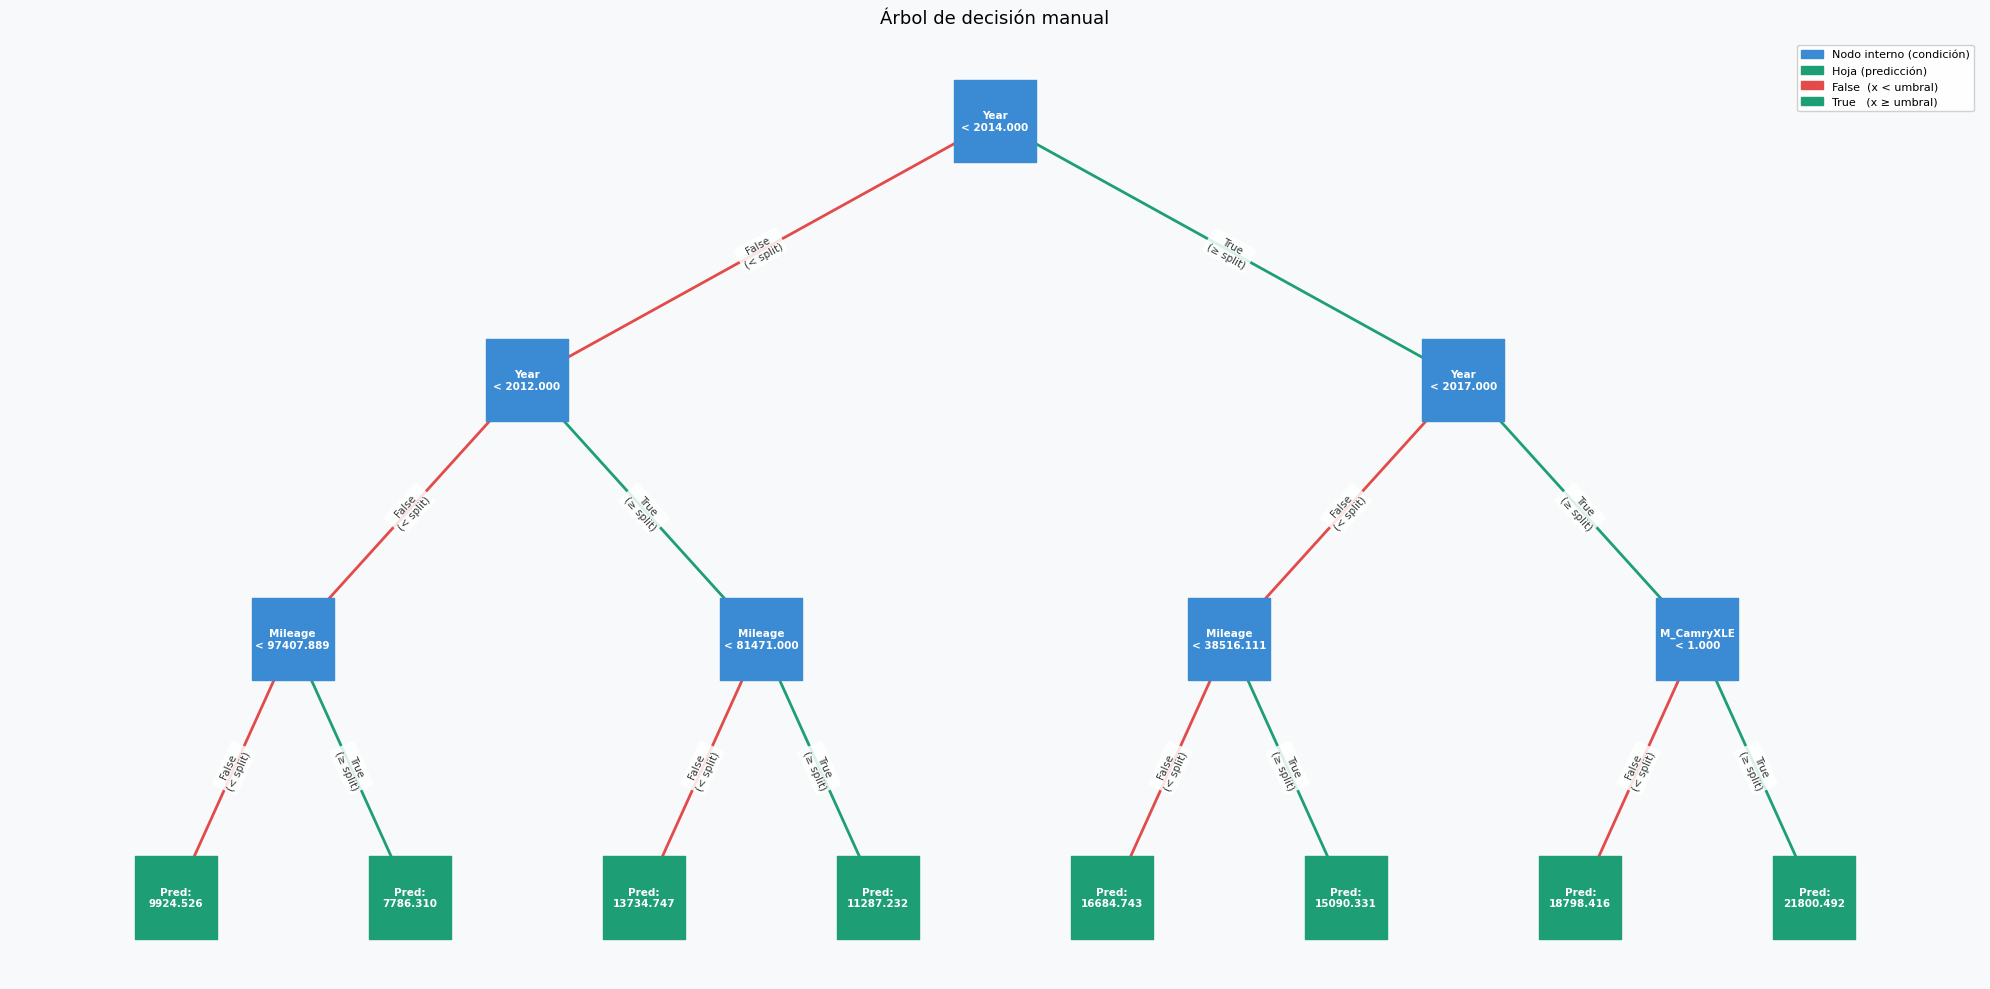

Leaf nodes : 8
RMSE       : $1,931.83
MAE        : $1,454.31


In [26]:
# ── Plot ──────────────────────────────────────────────────────────────────────
plot_tree(tree, feature_names=list(X_train.columns))

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = tree_predict(X_test.astype(float), tree)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"Leaf nodes : {count_leaves(tree)}")
print(f"RMSE       : ${rmse:,.2f}")
print(f"MAE        : ${mae:,.2f}")

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [27]:
# Celda 2

# Se crea un arreglo de 1 a 20
np.random.seed(1)

# Impresión de arreglo y muestreo aleatorio
nums = np.arange(1, 21)
print('Arreglo:', nums)
print('Muestreo aleatorio: ', np.random.choice(a=nums, size=20, replace=True))

# Creación de 10 muestras de bootstrap 
np.random.seed(123)

n_samples = X_train.shape[0]
n_B = 10

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_B +1 )]
samples

Arreglo: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Muestreo aleatorio:  [ 6 12 13  9 10 12  6 16  1 17  2 13  8 14  7 19  6 19 12 11]


[array([3582, 3454, 1346, ...,  826,  801, 5657],
       shape=(7031,), dtype=int32),
 array([6962, 3408, 2553, ..., 6611,  877, 6412],
       shape=(7031,), dtype=int32),
 array([1917, 3131,  384, ..., 2876, 6449, 6557],
       shape=(7031,), dtype=int32),
 array([3849, 4565, 6820, ..., 6835, 4643,  639],
       shape=(7031,), dtype=int32),
 array([2468, 3608, 1367, ..., 3108, 2961, 4357],
       shape=(7031,), dtype=int32),
 array([3142, 1537, 5966, ..., 3224, 6922, 3396],
       shape=(7031,), dtype=int32),
 array([6588, 3753, 1786, ..., 2131, 4627, 5672],
       shape=(7031,), dtype=int32),
 array([1289, 3776,  981, ..., 1891, 6034, 6165],
       shape=(7031,), dtype=int32),
 array([6079, 3819, 6976, ..., 6478, 2225, 5072],
       shape=(7031,), dtype=int32),
 array([3952, 3276,  896, ..., 4589, 1964,  893],
       shape=(7031,), dtype=int32)]

In [28]:
# Visualización muestra boostrap #1 para entremiento
X_train.iloc[samples[0], :]

,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
151599,2016.0,40999.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
171999,2014.0,52527.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
304172,2009.0,123202.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
74828,2015.0,38807.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
192974,2005.0,51260.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
134843,2014.0,22221.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
325075,2013.0,86593.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
61213,2014.0,28044.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
181222,2016.0,49368.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [52]:
# Construcción un árbol de decisión para cada muestra boostrap

from sklearn.tree import DecisionTreeRegressor

# Definición del modelo usando DecisionTreeRegressor de sklearn
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# DataFrame para guardar las predicciones de cada árbol
y_pred = pd.DataFrame(index=y_test.index, columns=[list(range(n_B))])

In [53]:
y_pred.shape

(3464, 10)

In [58]:
# Entrenamiento de un árbol sobre cada muestra boostrap y predicción sobre los datos de test
for i, sample in enumerate(samples):
    X_boot = X_train.iloc[sample, :]
    y_boot = y_train.iloc[sample]
    treereg.fit(X_boot, y_boot)
    y_pred.iloc[:, i] = treereg.predict(X_test)

y_pred

,0,1,2,3,4,5,6,7,8,9
257343,14980.0,13993.0,13649.0,13649.0,11788.0,13649.0,13993.0,13990.0,13990.0,13993.0
326011,6492.0,5995.0,5995.0,6987.0,5995.0,5995.0,5995.0,6987.0,5995.0,5995.0
242354,16491.0,16995.0,16491.0,15997.0,15997.0,16491.0,17591.0,16995.0,17404.0,16491.0
266376,21990.0,21990.0,22500.0,21990.0,15900.0,21990.0,22500.0,21990.0,15813.0,21990.0
396954,15988.0,16951.0,15988.0,15988.0,15988.0,17900.0,16951.0,16951.0,15988.0,15988.0
...,...,...,...,...,...,...,...,...,...,...
144298,13836.0,14800.0,14800.0,14800.0,14800.0,14681.0,14800.0,14800.0,13836.0,13836.0
364521,15999.0,14995.0,15999.0,16900.0,15999.0,15999.0,17300.0,15999.0,16900.0,15000.0
120072,23533.0,23533.0,20000.0,17700.0,17700.0,23533.0,17700.0,23533.0,23533.0,20000.0
99878,12989.0,12995.0,12989.0,12995.0,12991.0,12991.0,10995.0,12991.0,12991.0,12893.0


In [59]:
# Desempeño de cada árbol
for i in range(n_B):
    print('Árbol ', i, 'tiene un error: ', np.sqrt(mean_squared_error(y_pred.iloc[:,i], y_test)))

Árbol  0 tiene un error:  2141.613353645869
Árbol  1 tiene un error:  2136.3519863123465
Árbol  2 tiene un error:  2122.718759132052
Árbol  3 tiene un error:  2087.278992468617
Árbol  4 tiene un error:  2168.518742842026
Árbol  5 tiene un error:  2113.8811455834793
Árbol  6 tiene un error:  2127.933470769012
Árbol  7 tiene un error:  2184.414847251443
Árbol  8 tiene un error:  2138.1071697514985
Árbol  9 tiene un error:  2132.097520859104


In [60]:
# Predicciones promedio para cada obserbación del set de test
y_pred.mean(axis=1)

257343    13767.4
326011     6243.1
242354    16694.3
266376    20865.3
396954    16468.1
           ...   
144298    14498.9
364521    16109.0
120072    21076.5
99878     12782.0
387162    11957.4
Length: 3464, dtype: object

In [ ]:
# Error al promediar las predicciones de todos los árboles
rmse_bagg_manual = np.sqrt(mean_squared_error(y_test, y_pred.mean(axis=1)))
mae_bagg_manual = mean_absolute_error(y_test, y_pred.mean(axis=1))

print(f'valor del RMSE bagging manual {rmse_bagg_manual}')
print(f'valor del MAE bagging manual {mae_bagg_manual}')


valor del RMSE 1796.4355868399332
valor del MAE 1340.0160739030025


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [68]:
# Celda 3

from sklearn.ensemble import BaggingRegressor

# Definicion del arbol con log(n_features)
n_features = X_train.shape[1]
max_feat = int(np.log(n_features))  # log(n_features)
print(f"n_features: {n_features} - max_features (log): {max_feat}")

base_tree = DecisionTreeRegressor(
    max_features=max_feat,
    random_state=123
)

bagging_model = BaggingRegressor(
    estimator=base_tree,
    n_estimators=10,
    random_state=123
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bagging  = mean_absolute_error(y_test, y_pred_bagging)

print(f'valor del RMSE bagging con sklearn {rmse_bagging}')
print(f'valor del MAE bagging con sklearn {mae_bagging}')

print("\nComparación de modelos:")
print(f"{'Modelo':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 47)
print(f"{'Bagging Manual':<25} ${rmse_bagg_manual:>9,.2f} ${mae_bagg_manual:>9,.2f}")
print(f"{'Bagging sklearn':<25} ${rmse_bagging:>9,.2f} ${mae_bagging:>9,.2f}")

n_features: 9 - max_features (log): 2
valor del RMSE bagging con sklearn 1819.8090027247092
valor del MAE bagging con sklearn 1362.4093684473405

Comparación de modelos:
Modelo                          RMSE        MAE
-----------------------------------------------
Bagging Manual            $ 1,796.44 $ 1,340.02
Bagging sklearn           $ 1,819.81 $ 1,362.41


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [72]:
# Celda 4

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=10,      # mismo número de árboles que los modelos anteriores
    random_state=123
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print(f'valor del RMSE Random Forest con sklearn {rmse_rf}')
print(f'valor del MAE Random Forest con sklearn {mae_rf}')

print("\nComparación de modelos:")
print(f"{'Modelo':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 47)
print(f"{'Bagging Manual':<25} ${rmse_bagg_manual:>9,.2f} ${mae_bagg_manual:>9,.2f}")
print(f"{'Bagging sklearn':<25} ${rmse_bagging:>9,.2f} ${mae_bagging:>9,.2f}")
print(f"{'Random Forest sklearn':<25} ${rmse_rf:>9,.2f} ${mae_rf:>9,.2f}")

valor del RMSE Random Forest con sklearn 1805.1476087562717
valor del MAE Random Forest con sklearn 1348.1288834588877

Comparación de modelos:
Modelo                          RMSE        MAE
-----------------------------------------------
Bagging Manual            $ 1,796.44 $ 1,340.02
Bagging sklearn           $ 1,819.81 $ 1,362.41
Random Forest sklearn     $ 1,805.15 $ 1,348.13


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [75]:
# Celda 5

from sklearn.model_selection import GridSearchCV

# grid de hiperparámetros
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth':    [None, 5, 10, 20],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_tuned = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=1),
    param_grid = param_grid,
    scoring    = 'neg_root_mean_squared_error', # Parametro de optimizacion para seleccion luego del tunning - RMSE
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

rf_tuned.fit(X_train, y_train)

# Seleccion de los mejores parametros
print(rf_tuned.best_params_)

# Predicciion del modelo
best_rf = rf_tuned.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

# Metricas 
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
#Resultados
print(f'valor del RMSE Random Forest con sklearn  {rmse_rf}')
print(f'valor del MAE Random Forest con sklearn {mae_rf}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
valor del RMSE Random Forest con sklearn  1805.1476087562717
valor del MAE Random Forest con sklearn 1348.1288834588877


In [80]:
from sklearn.model_selection import cross_val_score
pd.Series(cross_val_score(rf_model, X, y, cv=10)).describe()

count    10.000000
mean      0.794505
std       0.012483
min       0.772591
25%       0.785970
50%       0.797776
75%       0.800848
max       0.810512
dtype: float64

#### Calibrar max_depth

In [ ]:
# Creación de lista de valores para iterar sobre diferentes valores de max_depth
depth_range = list(range(1, 31)) + [None]

# Definición de lista para almacenar el RMSE para cada valor de max_depth
rmse_scores_depth = []

# Uso de un 10-fold cross-validation para cada valor de max_depth
for depth in depth_range:
    clf = RandomForestRegressor(
        max_depth=depth,
        random_state=1,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )
    
    rmse_scores_depth.append(-scores.mean())

Text(0, 0.5, 'rmse')

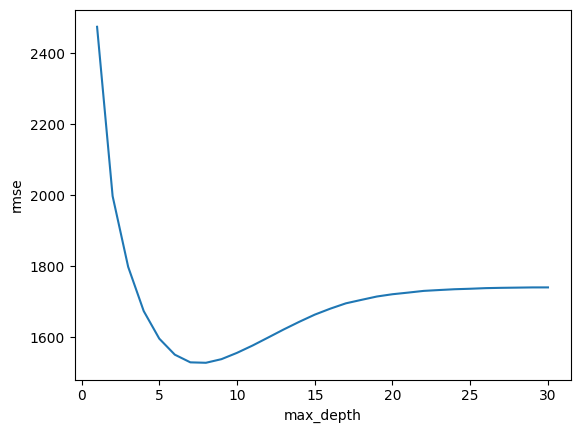

In [162]:
# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.plot(depth_range, rmse_scores_depth)
plt.xlabel('max_depth')
plt.ylabel('rmse')

In [170]:
best_rmse_depth = min(rmse_scores_depth)
best_depth = depth_range[rmse_scores_depth.index(best_rmse_depth)]
print(f"Best max_depth: {best_depth} with RMSE: {best_rmse_depth:.4f}")

Best max_depth: 8 with RMSE: 1528.1659


#### Calibrar n_estimators

In [ ]:
# Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(10, 310, 10)

# Definición de lista para almacenar el RMSE para cada valor de n_estimators
rmse_scores_estimator = []

# Uso de un 10-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    clf = RandomForestRegressor(
        n_estimators=estimator,
        max_depth = best_depth,
        random_state=1,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        clf, X_train, y_train,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )
    
    rmse_scores_estimator.append(-scores.mean())

Text(0, 0.5, 'rmse')

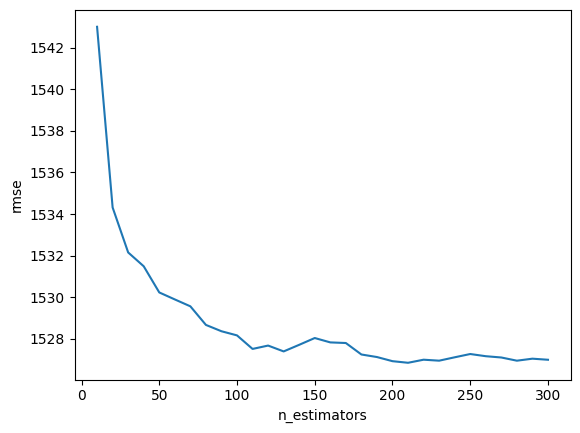

In [173]:
# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.plot(estimator_range, rmse_scores_estimator)
plt.xlabel('n_estimators')
plt.ylabel('rmse')

In [174]:
best_rmse_estimator = min(rmse_scores_estimator)
best_estimador = estimator_range[rmse_scores_estimator.index(best_rmse_estimator)]
print(f"Best n_estimators: {best_estimador} with RMSE: {best_rmse_estimator:.4f}")

Best n_estimators: 210 with RMSE: 1526.8491


#### Calibrar max_features

In [175]:
feature_cols = X.columns

In [ ]:
# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(1, len(feature_cols)+1)

# Definición de lista para almacenar el RMSE para cada valor de max_features
rmse_scores_feature = []

# Uso de un 10-fold cross-validation para cada valor de max_features

for feature in feature_range:
    clf = RandomForestRegressor(
        n_estimators=best_estimador,
        max_depth = best_depth,
        max_features=feature,
        random_state=1,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        clf, X_train, y_train,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )
    
    rmse_scores_feature.append(-scores.mean())

Text(0, 0.5, 'rmse')

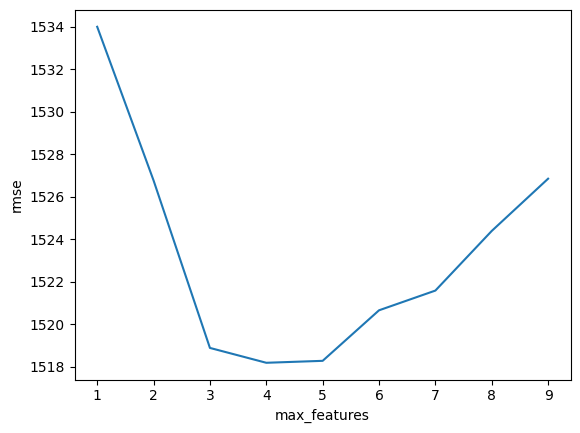

In [177]:
# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.plot(feature_range, rmse_scores_feature)
plt.xlabel('max_features')
plt.ylabel('rmse')

In [180]:
best_rmse_feature = min(rmse_scores_feature)
best_feature = feature_range[rmse_scores_feature.index(best_rmse_feature)]

print(f"Best max_features: {best_feature} with RMSE: {best_rmse_feature:.4f}")



Best max_features: 4 with RMSE: 1518.1770


In [182]:
# Definición del modelo con los parámetros calibrados
rf_tunned = RandomForestRegressor(n_estimators=best_estimador, max_depth=best_depth, max_features=best_feature, random_state=1, n_jobs=-1)

rf_tunned.fit(X_train, y_train)
y_pred_rf = rf_tunned.predict(X_test)

rmse_rf_tunned = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf_tunned  = mean_absolute_error(y_test, y_pred_rf)

print(f'valor del RMSE Random Forest con calibracion {rmse_rf_tunned}')
print(f'valor del MAE Random Forest con calibracion {mae_rf_tunned}')

valor del RMSE Random Forest con calibracion 1552.8465916969476
valor del MAE Random Forest con calibracion 1139.2015366066182


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [183]:
# Celda 6

from xgboost import XGBRegressor
xgbregre = XGBRegressor()
xgbregre.fit(X_train, y_train)
y_pred_XGB = xgbregre.predict(X_test)

# Metricas 
rmse_XGB= np.sqrt(mean_squared_error(y_test, y_pred_XGB))
mae_XGB  = mean_absolute_error(y_test, y_pred_XGB)

print(f'valor del RMSE XGBoost  {rmse_XGB}')
print(f'valor del MAE XGBoost {mae_XGB}')


valor del RMSE XGBoost  1605.2355199928948
valor del MAE XGBoost 1185.2272991506386


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [159]:
# Celda 7


### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [160]:
# Celda 8
